In [182]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

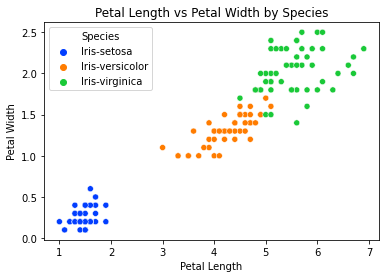

In [183]:
df = pd.read_csv("Iris.csv")
df.drop(columns=["Id"], inplace=True)
sns.scatterplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    data=df,
    palette="bright"
)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title("Petal Length vs Petal Width by Species")
plt.show()

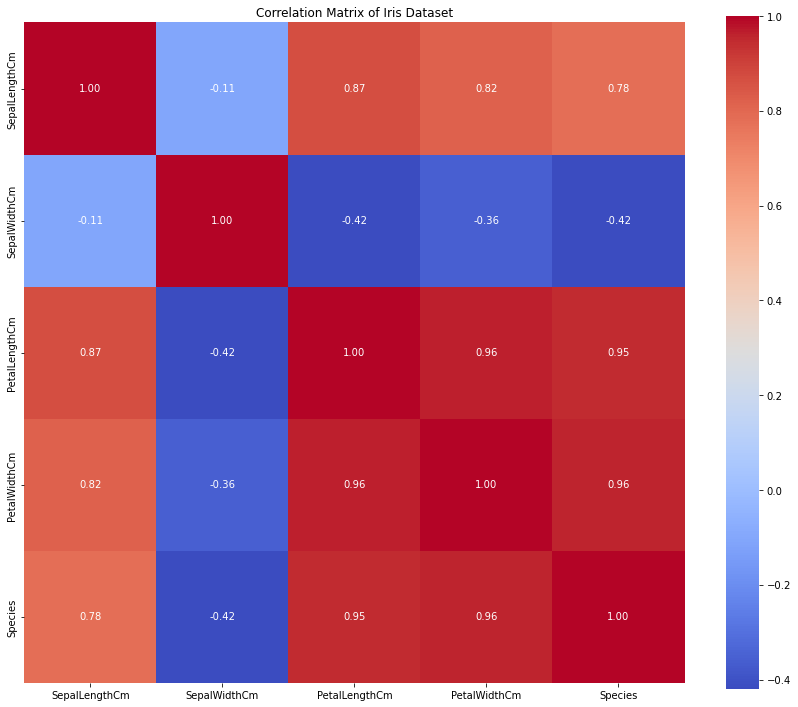

In [184]:
encoder = LabelEncoder()
df["Species"] = encoder.fit_transform(df["Species"])

# Correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Correlation Matrix of Iris Dataset")
plt.tight_layout()
plt.show()

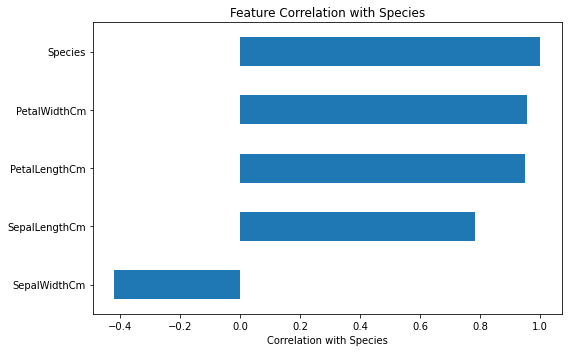

In [185]:
species_corr = corr_matrix["Species"].sort_values(ascending=False)
plt.figure(figsize=(8, 5))
species_corr.plot(kind="barh")
plt.xlabel("Correlation with Species")
plt.title("Feature Correlation with Species")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [199]:
X = df.drop(columns=["Species"]).values
y = df["Species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [200]:
class BinaryLogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=3000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.W = None
        self.b = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.W) + self.b
            y_hat = self.sigmoid(linear_model)

            dW = (1 / n_samples) * np.dot(X.T, (y_hat - y))
            db = (1 / n_samples) * np.sum(y_hat - y)

            self.W -= self.lr * dW
            self.b -= self.lr * db
            loss = -np.mean(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9))
            self.loss_history.append(loss)

    def predict_proba(self, X):
        linear_model = np.dot(X, self.W) + self.b
        return self.sigmoid(linear_model)

In [201]:
class OneVsRestLogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=3000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.classifiers = []
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.classifiers = []

        for cls in self.classes:
            print(f"Training classifier for class {cls}")
            y_binary = (y == cls).astype(int)
            clf = BinaryLogisticRegression(
                learning_rate=self.lr,
                n_iterations=self.n_iterations
            )
            clf.fit(X, y_binary)
            self.classifiers.append(clf)

    def predict(self, X):
        probs = np.zeros((X.shape[0], len(self.classifiers)))
        for idx, clf in enumerate(self.classifiers):
            probs[:, idx] = clf.predict_proba(X)
        return np.argmax(probs, axis=1)


In [202]:
model_ovr = OneVsRestLogisticRegression(
    learning_rate=0.1,
    n_iterations=9000
)

model_ovr.fit(X_train, y_train)
y_pred = model_ovr.predict(X_test)

Training classifier for class 0
Training classifier for class 1
Training classifier for class 2


In [203]:
acc = accuracy_score(y_test, y_pred)
print("OvR Test Accuracy:", acc)

OvR Test Accuracy: 0.9555555555555556


In [204]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[16  1  0]
 [ 0 14  1]
 [ 0  0 13]]


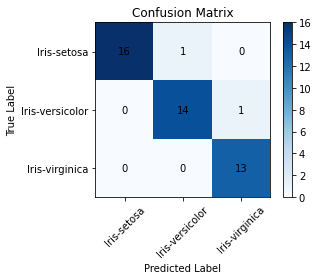

In [205]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

class_names = encoder.classes_

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

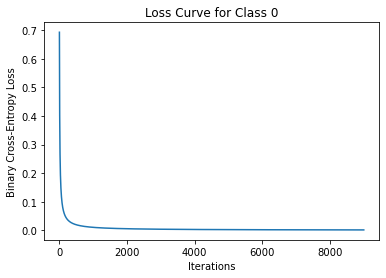

In [206]:
plt.plot(model_ovr.classifiers[0].loss_history)
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curve for Class 0")
plt.show()

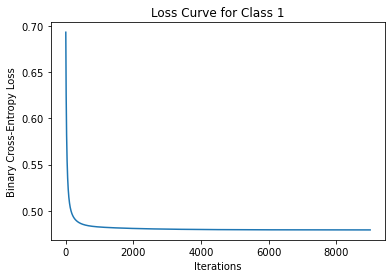

In [207]:
plt.plot(model_ovr.classifiers[1].loss_history)
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curve for Class 1")
plt.show()

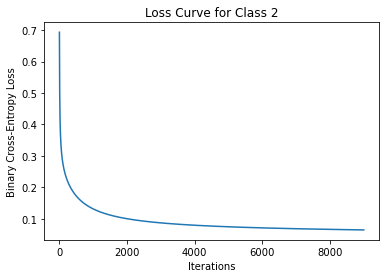

In [208]:
plt.plot(model_ovr.classifiers[2].loss_history)
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curve for Class 2")
plt.show()